In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")

In [2]:
df = pd.read_csv("music_streams.csv")

In [3]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [4]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

#Histogram

<Axes: xlabel='streams_millions', ylabel='Count'>

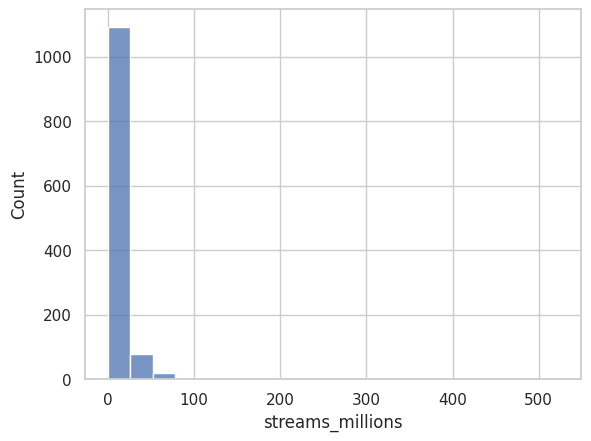

In [6]:
sns.histplot(data=df, x="streams_millions", bins=20)

#monthly streams

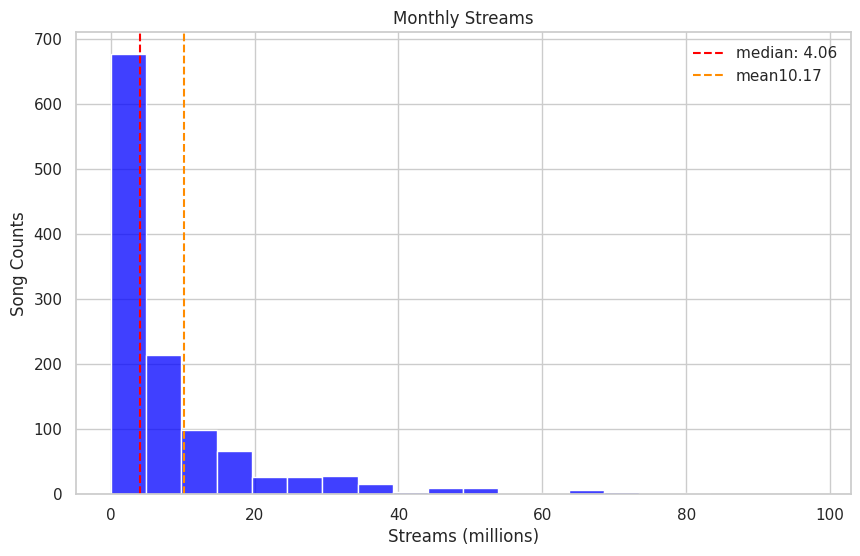

In [20]:
from matplotlib.lines import lineStyles
from ipywidgets import Label
fig, ax = plt.subplots(figsize=(10, 6))
median = df.streams_millions.median()
mean = df.streams_millions.mean()

sns.histplot(data=df[df.streams_millions < 100], x="streams_millions", bins=20, ax = ax, color="blue")

ax.axvline(median, label = f"median: {median:.2f}", color="red", linestyle="--")
ax.axvline(mean, label = f"mean{mean:.2f}", color="darkorange", linestyle="--")

ax.set_xlabel("Streams (millions)")
ax.set_ylabel("Song Counts")
ax.set_title("Monthly Streams")

ax.legend(frameon=False)
plt.show()

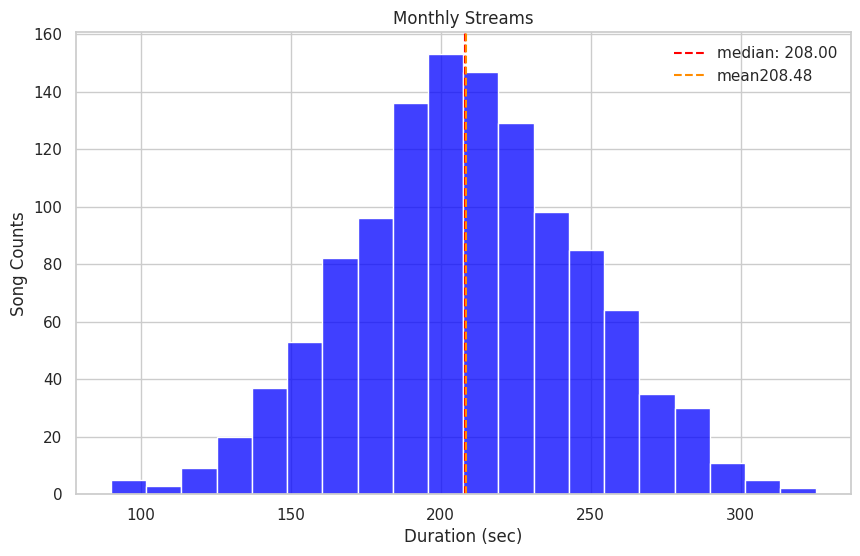

In [79]:
from matplotlib.lines import lineStyles
from ipywidgets import Label

fig, ax = plt.subplots(figsize=(10, 6))
median = df.duration_sec.median()
mean = df.duration_sec.mean()

sns.histplot(data=df, x="duration_sec", bins=20, ax = ax, color="blue")

ax.axvline(median, label = f"median: {median:.2f}", color="red", linestyle="--")
ax.axvline(mean, label = f"mean{mean:.2f}", color="darkorange", linestyle="--")

ax.set_xlabel("Duration (sec)")
ax.set_ylabel("Song Counts")
ax.set_title("Monthly Streams")

ax.legend(frameon=False)
plt.show()

#boxplots

In [28]:
orderHighEnergy = df.groupby("genre")["energy"].mean().sort_values(ascending=False).index
orderHighEnergy

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

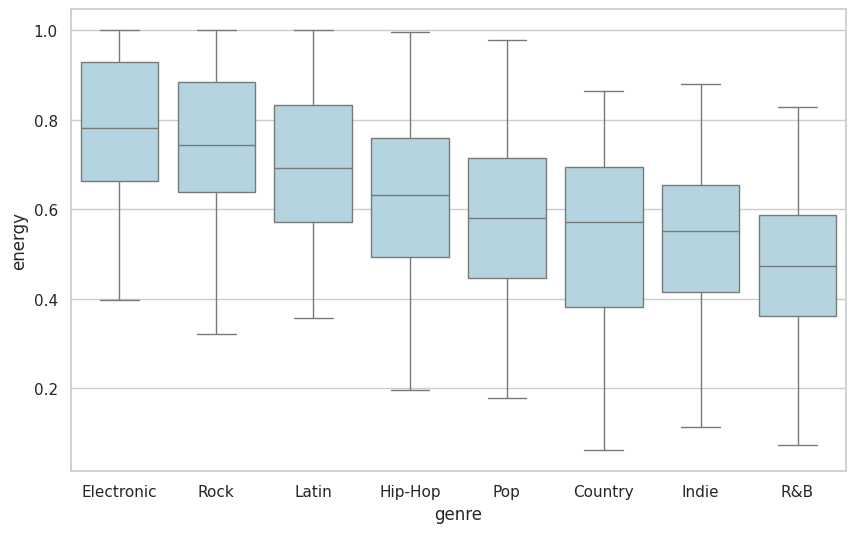

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, y="energy", x="genre", order=orderHighEnergy, ax=ax, color="lightblue")

In [33]:
orderHighTempo = df.groupby("genre")["tempo_bpm"].mean().sort_values(ascending=False).index
orderHighTempo

Index(['R&B', 'Hip-Hop', 'Pop', 'Country', 'Rock', 'Electronic', 'Latin',
       'Indie'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='tempo_bpm'>

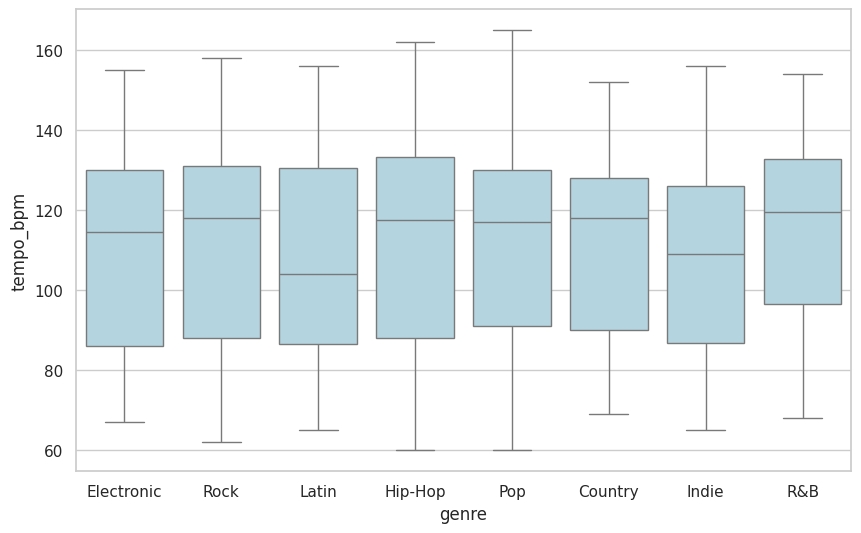

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, y="tempo_bpm", x="genre", order=orderHighEnergy, ax=ax, color="lightblue")

#Scatterplot

<Axes: xlabel='energy', ylabel='danceability'>

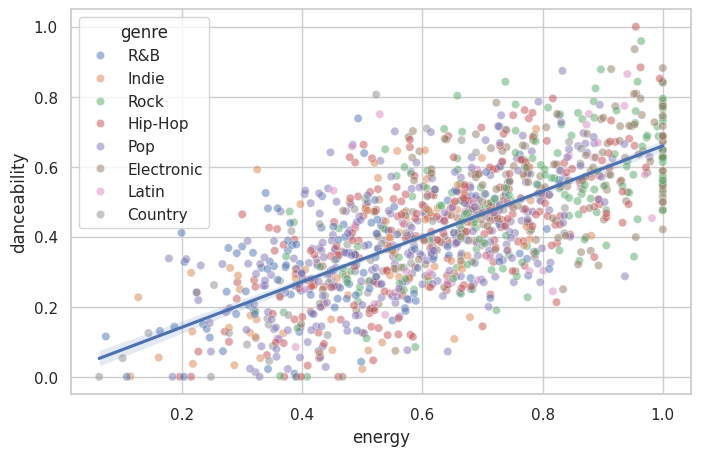

In [42]:
sample = df.sample(1000)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="energy", y="danceability", hue="genre", color="grey", alpha=0.5)
sns.regplot(data=df, x="energy", y="danceability", scatter = False)

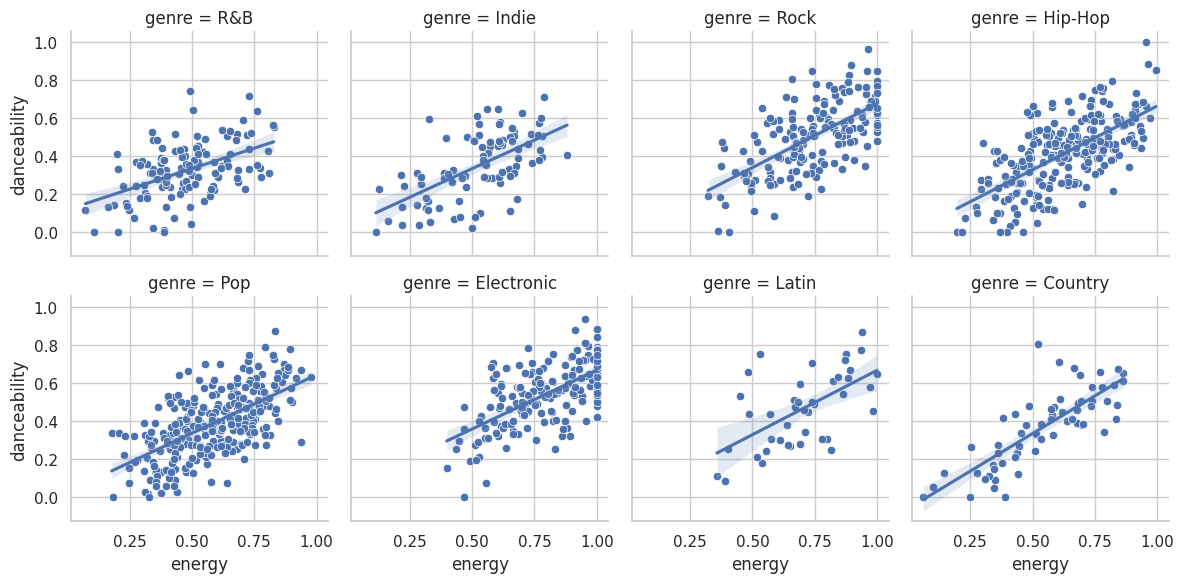

In [44]:
g=sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")
g.map(sns.regplot, "energy", "danceability", scatter=False)

<Axes: xlabel='streams_millions', ylabel='monthly_listeners'>

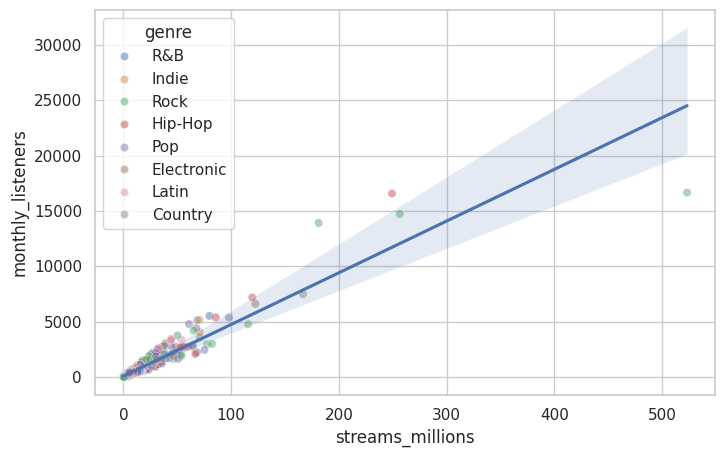

In [45]:
sample = df.sample(1000)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="streams_millions", y="monthly_listeners", hue="genre", color="grey", alpha=0.5)
sns.regplot(data=df, x="streams_millions", y="monthly_listeners", scatter = False)

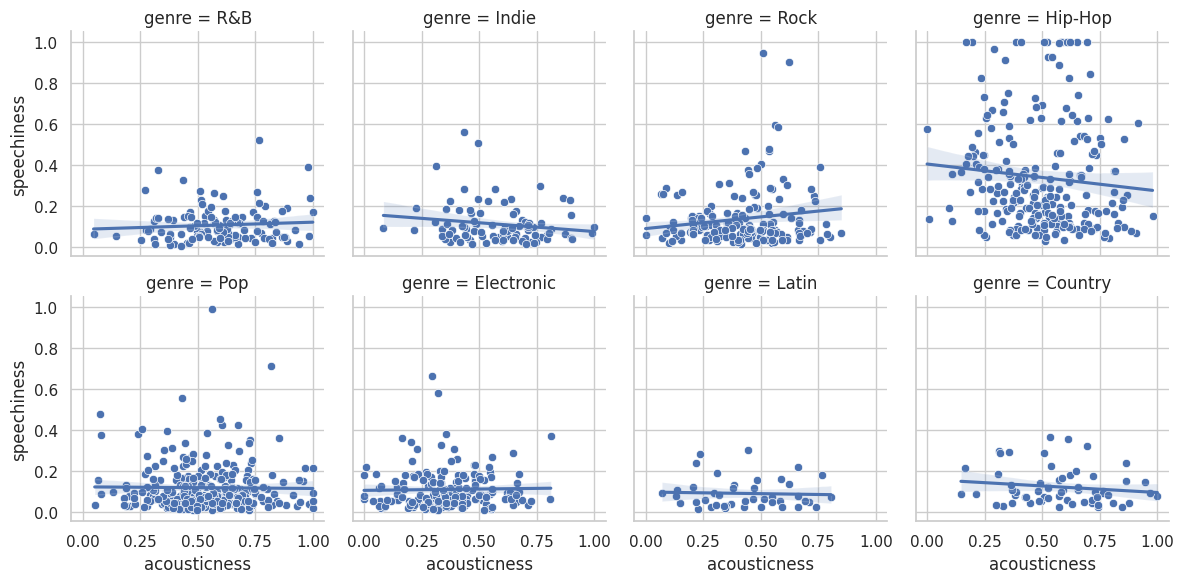

In [47]:
g=sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "acousticness", "speechiness")
g.map(sns.regplot, "acousticness", "speechiness", scatter=False)

#line charts

In [85]:
df.head(20)

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds
5,TRK00006,Wasted Tears Still,Obsidian Coast,Pop,2023,3:07,187,106,F# Minor,0.494,...,0.557,0.674,0.423,-12.0,False,1.44,153,1540,200.0,Secretly Canadian
6,TRK00007,Electric Silence,Axel Voss ft. Skye Monroe,R&B,2021,3:29,209,144,F Minor,0.685,...,0.723,0.394,0.130,-7.6,True,0.46,2,420,110.0,Secretly Canadian
7,TRK00008,Days,Cleo Cruz,Indie,2021,2:39,159,78,B Minor,0.114,...,0.566,0.899,0.154,-13.0,False,2.24,157,1587,NaN,Sub Pop
8,TRK00009,Blazing Tears,Juno Reid ft. Marcus Fox,Hip-Hop,2021,2:02,122,146,B Major,0.494,...,0.469,0.655,0.741,-8.8,True,1.97,102,4133,6.0,A24 Sounds
9,TRK00010,Blazing Roads Now,Devon Laurent,Hip-Hop,2021,3:44,224,115,A Minor,0.821,...,0.706,0.222,0.555,-2.5,False,14.84,764,19932,1.0,Warner Music


In [49]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [53]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()
pop_trend

,streams_millions
year,
2015,7.160
2016,3.540
2017,3.560
2018,11.370
2019,4.720
2020,5.075
2021,3.645
2022,4.445
2023,4.230


In [56]:
df.genre.unique()

array(['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin',
       'Country'], dtype=object)

In [65]:
genres = ["R&B", "Indie", "Rock", "Hip-Hop", "Pop"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median()

print(trend)

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.plot(pop_trend.index, pop_trend)

year  genre  
2015  Hip-Hop     5.755
      Indie      13.900
      Pop         7.160
      R&B         3.590
      Rock        4.800
2016  Hip-Hop     5.650
      Indie       3.720
      Pop         3.540
      R&B         5.840
      Rock        5.390
2017  Hip-Hop     4.660
      Indie       2.130
      Pop         3.560
      R&B         3.910
      Rock        5.150
2018  Hip-Hop     4.590
      Indie       6.385
      Pop        11.370
      R&B         5.520
      Rock        3.060
2019  Hip-Hop     3.080
      Indie       2.380
      Pop         4.720
      R&B         5.080
      Rock        5.120
2020  Hip-Hop     3.285
      Indie       4.365
      Pop         5.075
      R&B         2.380
      Rock        4.525
2021  Hip-Hop     4.155
      Indie       3.410
      Pop         3.645
      R&B         2.130
      Rock        3.820
2022  Hip-Hop     4.200
      Indie       5.480
      Pop         4.445
      R&B         2.310
      Rock        3.340
2023  Hip-Hop     3.670
  

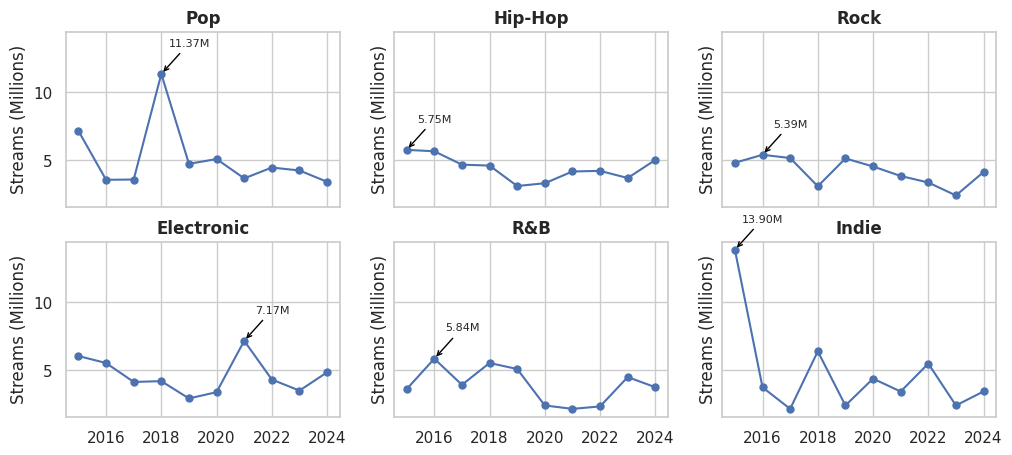

In [77]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B","Indie"]
trend = df[df.genre.isin(genres)].groupby(["year","genre"]) ["streams_millions"].median().reset_index()
fig, axes = plt.subplots(2,3,figsize=(12,5),sharex=True, sharey=True)
axes = axes. flatten()

for ax, genre in zip(axes, genres):
  subD = trend [trend.genre == genre]
  ax.plot(subD.year, subD.streams_millions, marker="o", ms="5")

  peak = subD.loc[subD.streams_millions.idxmax()]
  ax.annotate(f"{peak.streams_millions:.2f}M", xy = (peak.year, peak.streams_millions),
              xytext = (20, 20), textcoords="offset points", ha="center", fontsize = 8,
              arrowprops=dict(arrowstyle="->", color="black"))

  ax.set_title(genre, fontweight="bold")
  ax.set_ylabel("Streams (Millions)")

In [81]:
df.label.unique()

array(['AWAL', 'A24 Sounds', 'Dead Oceans', 'Sony Music',
       'Secretly Canadian', 'Sub Pop', 'Warner Music', 'Beggars Group',
       'Big Machine', 'Universal Music', 'Concord', 'Interscope',
       'Jagjaguwar'], dtype=object)

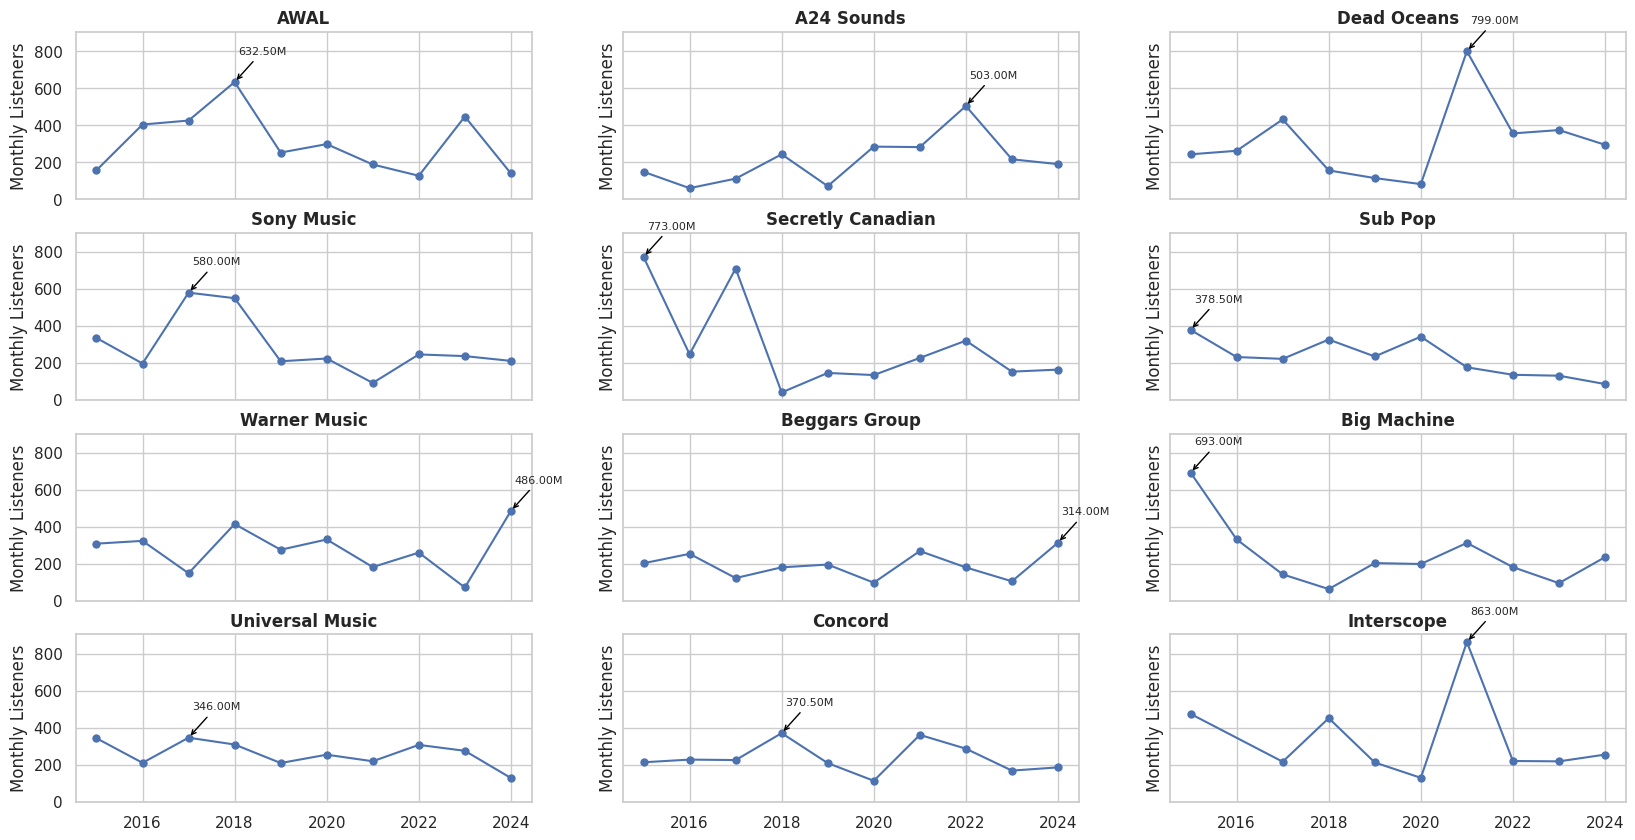

In [93]:
labels = ['AWAL', 'A24 Sounds', 'Dead Oceans', 'Sony Music',
       'Secretly Canadian', 'Sub Pop', 'Warner Music', 'Beggars Group',
       'Big Machine', 'Universal Music', 'Concord', 'Interscope',
       'Jagjaguwar']
trend = df[df.label.isin(labels)].groupby(["year","label"]) ["monthly_listeners"].median().reset_index()
fig, axes = plt.subplots(4,3,figsize=(20,10),sharex=True, sharey=True)
axes = axes. flatten()

for ax, label in zip(axes, labels):
  subD = trend [trend.label == label]
  ax.plot(subD.year, subD.monthly_listeners, marker="o", ms="5")

  peak = subD.loc[subD.monthly_listeners.idxmax()]
  ax.annotate(f"{peak.monthly_listeners:.2f}M", xy = (peak.year, peak.monthly_listeners),
              xytext = (20, 20), textcoords="offset points", ha="center", fontsize = 8,
              arrowprops=dict(arrowstyle="->", color="black"))

  ax.set_title(label, fontweight="bold")
  ax.set_ylabel("Monthly Listeners")

#Vega-Altair

In [90]:
import altair as alt
import pandas as pd

df["explicit_label"] = df["explicit"].map({
    True: "Explicit",
    False: "Clean"
})

genre_explicit = (
    df.groupby(["genre", "explicit_label"], as_index=False)
      .agg(
          avg_streams_millions=("streams_millions", "mean"),
          song_count=("track_id", "count")
      )
)

alt.Chart(genre_explicit).mark_bar(
    cornerRadiusTopLeft=4,
    cornerRadiusTopRight=4
).encode(
    x=alt.X(
        "genre:N",
        title="Genre",
        sort=alt.EncodingSortField(
            field="avg_streams_millions",
            op="mean",
            order="descending"
        )
    ),
    xOffset=alt.XOffset("explicit_label:N"),
    y=alt.Y(
        "avg_streams_millions:Q",
        title="Average Streams (Millions)"
    ),
    color=alt.Color(
        "explicit_label:N",
        title="Song Type"
    ),
    tooltip=[
        alt.Tooltip("genre:N", title="Genre"),
        alt.Tooltip("explicit_label:N", title="Song Type"),
        alt.Tooltip("avg_streams_millions:Q", title="Average Streams", format=".2f"),
        alt.Tooltip("song_count:Q", title="Number of Songs")
    ]
).properties(
    width=650,
    height=350,
    title="Average Streams by Genre and Explicit Status"
)

alt.Chart(...)